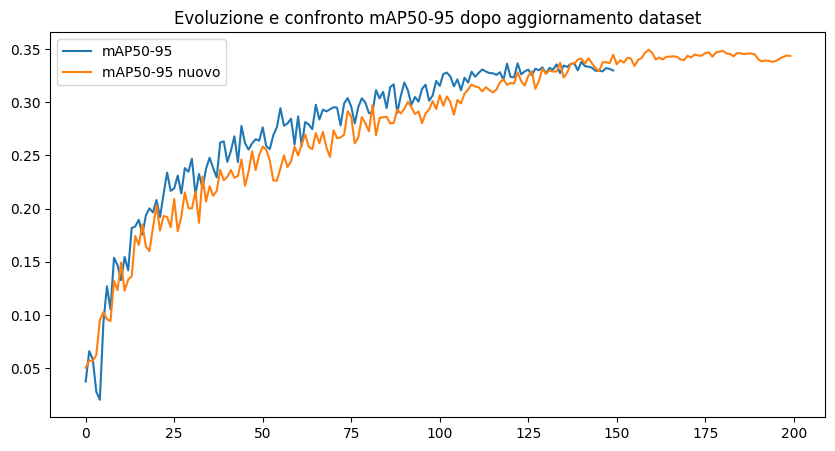

In [21]:
import pandas as pd 
import matplotlib.pyplot as plt

resultsLargeOld = pd.read_csv('versioniPrecedenti/runs/segment26/large/modello26_large_150_64/results.csv')
resultsLargeOld.columns = resultsLargeOld.columns.str.strip()

resultsLargeNew = pd.read_csv('runs/segment/large26_200_32/results.csv')
resultsLargeNew.columns = resultsLargeNew.columns.str.strip()

plt.figure(figsize=(10,5))
plt.plot(resultsLargeOld['metrics/mAP50-95(M)'], label='mAP50-95')

plt.plot(resultsLargeNew['metrics/mAP50-95(M)'], label='mAP50-95 nuovo', )
plt.legend()

plt.title('Evoluzione e confronto mAP50-95 dopo aggiornamento dataset')
plt.show()

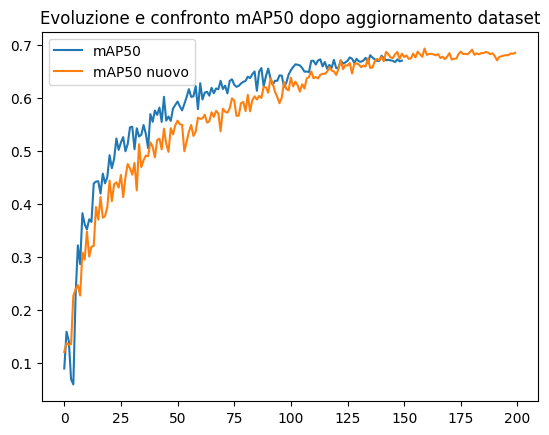

In [22]:
plt.plot(resultsLargeOld['metrics/mAP50(M)'], label='mAP50')

plt.plot(resultsLargeNew['metrics/mAP50(M)'], label='mAP50 nuovo', )
plt.legend()

plt.title('Evoluzione e confronto mAP50 dopo aggiornamento dataset')
plt.show()

C'è un problema di over saturation con l'extraLarge, 

In [23]:
small = pd.read_csv('runs/segment/small26_200_32/results.csv')
medium = pd.read_csv('runs/segment/m26Finale/results.csv')
large = pd.read_csv('runs/segment/large26_200_32/results.csv')
extralarge = pd.read_csv('runs/segment/NuovoXL/results.csv')

plt.figure(figsize=(10,5))
plt.plot(small['metrics/mAP50-95(M)'], label='small26_200_32')
plt.plot(medium['metrics/mAP50-95(M)'], label='medium26_200_32')
plt.plot(large['metrics/mAP50-95(M)'], label='large26_200_32')
plt.plot(extralarge['metrics/mAP50-95(M)'], label='extraLarge26_200_32')

plt.legend()
plt.title('Confronto mAP50-95 tra modelli large, small e extraLarge')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'runs/segment/m26Finale/results.csv'

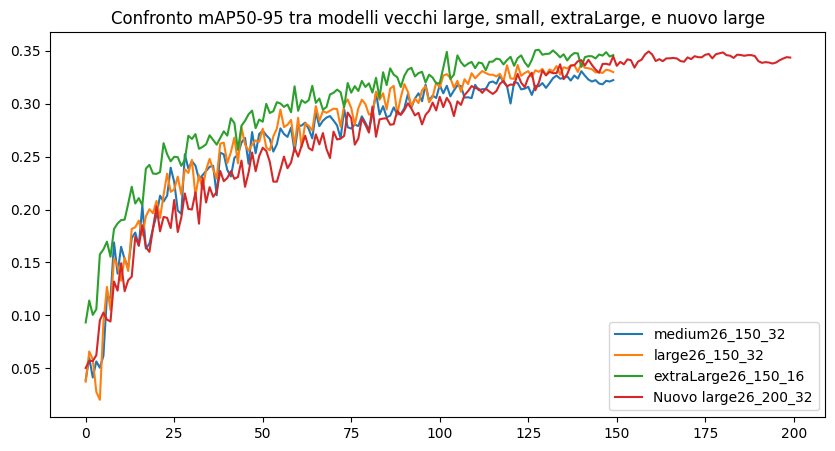

In [ ]:
mediumOld = pd.read_csv('versioniPrecedenti/runs/segment26/medium/modello26_medium_150_64/results.csv')
largeOld = pd.read_csv('versioniPrecedenti/runs/segment26/large/modello26_large_150_64/results.csv')
xlOld = pd.read_csv('versioniPrecedenti/runs/segment26/extraLarge/modello26_extraLarge_150/results.csv')

plt.figure(figsize=(10,5))
plt.plot(mediumOld['metrics/mAP50-95(M)'], label='medium26_150_32')
plt.plot(largeOld['metrics/mAP50-95(M)'], label='large26_150_32')
plt.plot(xlOld['metrics/mAP50-95(M)'], label='extraLarge26_150_16')
plt.plot(large['metrics/mAP50-95(M)'], label='Nuovo large26_200_32')

plt.legend()
plt.title('Confronto mAP50-95 tra modelli vecchi large, small, extraLarge, e nuovo large')
plt.show()

In [ ]:
def print_max_metrics(df, name, col='metrics/mAP50-95(M)'):
    """Stampa l'epoca e il valore massimo della metrica scelta."""
    aliases = {
        'mAP50-95': 'metrics/mAP50-95(M)',
        'mAP50-95(M)': 'metrics/mAP50-95(M)',
        'mAP50': 'metrics/mAP50(M)',
        'mAP50(M)': 'metrics/mAP50(M)',
        'precision(M)': 'metrics/precision(M)',
        'recall(M)': 'metrics/recall(M)',
        'mAP50(B)': 'metrics/mAP50(B)',
        'mAP50-95(B)': 'metrics/mAP50-95(B)',
        'precision(B)': 'metrics/precision(B)',
        'recall(B)': 'metrics/recall(B)'
    }
    if col not in df.columns and col in aliases:
        col = aliases[col]
    if col in df.columns:
        idx = df[col].idxmax()
        val = df[col].max()
        epoch = int(df.loc[idx, 'epoch']) if 'epoch' in df.columns else idx
        print(f"{name}: best epoch {epoch}, {col} = {val:.5f}")
    else:
        available = ', '.join(list(df.columns)[:40])
        print(f"{name}: column {col} not found. Available columns (sample): {available}")

print_max_metrics(small, 'small26_200_32', 'metrics/mAP50(M)')
print_max_metrics(large, 'large26_200_32', 'metrics/mAP50(M)')

print_max_metrics(mediumOld, 'medium26_150_64', 'metrics/mAP50(M)')
print_max_metrics(largeOld, 'large26_150_64', 'metrics/mAP50(M)')
print_max_metrics(xlOld, 'extraLarge26_150_32', 'metrics/mAP50(M)')


small26_200_32: best epoch 181, metrics/mAP50(M) = 0.65023
large26_200_32: best epoch 160, metrics/mAP50(M) = 0.69298
medium26_150_64: best epoch 122, metrics/mAP50(M) = 0.66283
large26_150_64: best epoch 136, metrics/mAP50(M) = 0.68025
extraLarge26_150_32: best epoch 103, metrics/mAP50(M) = 0.69816


| Model         | Dataset   |   Box_mAP50 |   Box_mAP50-95 |   Mask_mAP50 |   Mask_mAP50-95 |   Precision |   Recall |   Conf |
|:--------------|:----------|------------:|---------------:|-------------:|----------------:|------------:|---------:|-------:|
| Large 11      | NewData   |      0.8162 |         0.5701 |       0.7345 |          0.4073 |      0.7472 |   0.6845 |    0.2 |
| Large 11      | NewData   |      0.8111 |         0.5706 |       0.7342 |          0.4101 |      0.7472 |   0.6845 |    0.3 |
| Large 11      | NewData   |      0.8068 |         0.5719 |       0.732  |          0.4123 |      0.75   |   0.6813 |    0.4 |
| Large 11      | NewData   |      0.7979 |         0.5687 |       0.7258 |          0.4117 |      0.789  |   0.6506 |    0.5 |
| Large 11      | NewData   |      0.7915 |         0.5699 |       0.7224 |          0.4141 |      0.8031 |   0.6331 |    0.6 |
| Large 11      | NewData   |      0.7716 |         0.563  |       0.705  |          0.4119 |      0.8271 |   0.5795 |    0.7 |
| ExtraLarge 11 | NewData   |      0.808  |         0.5737 |       0.742  |          0.425  |      0.7502 |   0.6964 |    0.2 |
| ExtraLarge 11 | NewData   |      0.8064 |         0.5753 |       0.7417 |          0.4273 |      0.7508 |   0.6964 |    0.3 |
| ExtraLarge 11 | NewData   |      0.8028 |         0.5756 |       0.7405 |          0.429  |      0.7594 |   0.6896 |    0.4 |
| ExtraLarge 11 | NewData   |      0.7974 |         0.5752 |       0.7369 |          0.4298 |      0.7753 |   0.6731 |    0.5 |
| ExtraLarge 11 | NewData   |      0.7891 |         0.5731 |       0.7303 |          0.4297 |      0.7959 |   0.6458 |    0.6 |
| ExtraLarge 11 | NewData   |      0.7848 |         0.5742 |       0.7279 |          0.4326 |      0.82   |   0.6297 |    0.7 |
| Medium 11     | NewData   |      0.8015 |         0.5593 |       0.7186 |          0.3971 |      0.7592 |   0.6308 |    0.2 |
| Medium 11     | NewData   |      0.7983 |         0.5598 |       0.7173 |          0.3988 |      0.7592 |   0.6308 |    0.3 |
| Medium 11     | NewData   |      0.7957 |         0.5615 |       0.7167 |          0.4014 |      0.7226 |   0.6567 |    0.4 |
| Medium 11     | NewData   |      0.7891 |         0.5602 |       0.7139 |          0.4027 |      0.7481 |   0.6364 |    0.5 |
| Medium 11     | NewData   |      0.7765 |         0.5562 |       0.709  |          0.403  |      0.7764 |   0.6105 |    0.6 |
| Medium 11     | NewData   |      0.7649 |         0.5554 |       0.7034 |          0.4054 |      0.8174 |   0.5777 |    0.7 |

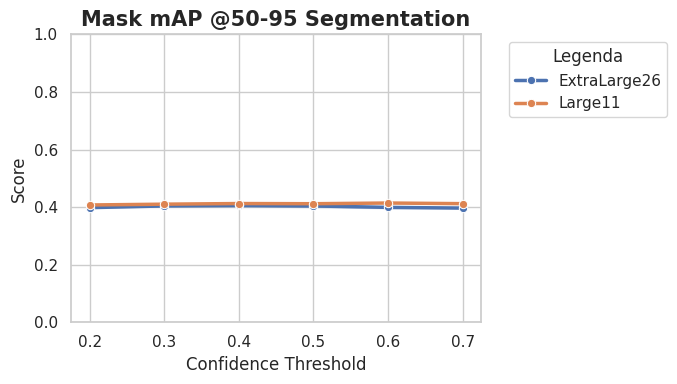

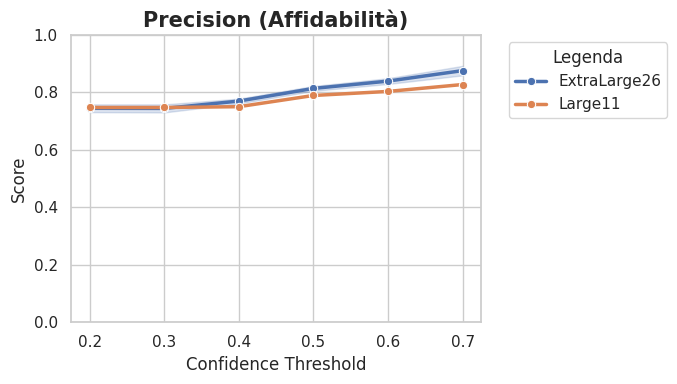

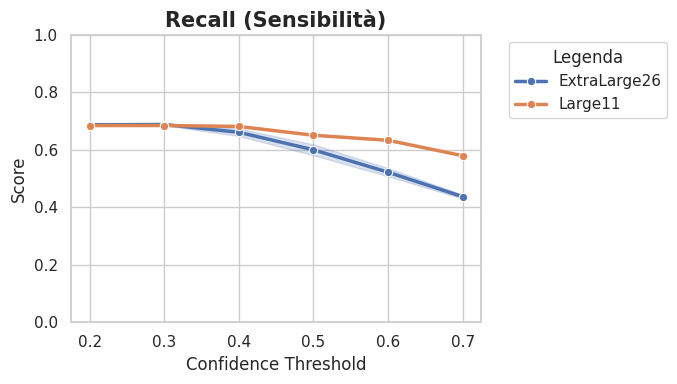

<Figure size 640x480 with 0 Axes>

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento dati
df = pd.read_csv('risultati.csv')

# Modelli scelti per il confronto
modelli_da_visualizzare = ['Large11', 'ExtraLarge26']

# Filtraggio e ordinamento
df_plot = df[df['Model'].isin(modelli_da_visualizzare)].copy()
df_plot = df_plot.sort_values(by=['Model', 'Conf'])

# Definizione metriche
metrics = ["Mask_mAP50-95", "Precision", "Recall"]
titles = ["Mask mAP @50-95 Segmentation", "Precision (Affidabilità)", "Recall (Sensibilità)"]

# --- OPZIONE A: Generazione di 3 Immagini Separate ---
sns.set_theme(style="whitegrid")
for i, metric in enumerate(metrics):
    plt.figure(figsize=(7, 4))
    sns.lineplot(
        data=df_plot,
        x='Conf',
        y=metric,
        hue='Model',
        marker='o',
        linewidth=2.5
    )
    plt.title(titles[i], fontsize=15, fontweight='bold')
    plt.xlabel("Confidence Threshold", fontsize=12)
    plt.ylabel("Score", fontsize=12)
    plt.ylim(0, 1.0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Legenda")
    plt.tight_layout()
 #   plt.savefig(f'confronto_{metric}.png', dpi=300)
    plt.show()

plt.suptitle(f"Analisi Comparativa: {', '.join(modelli_da_visualizzare)}", 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
#plt.savefig('confronto_completo_modelli.png', dpi=300)
plt.show()

    label  peso_mb  training_h  mask5095
YOLO26-XL    141.8        5.50    0.4080
 YOLO26-L     63.5        3.33    0.4070
 YOLO26-M     54.5        2.83    0.3970
 YOLO26-S     23.4        1.83    0.3790
YOLO11-XL    124.8        4.50    0.4290
 YOLO11-L     55.8        2.67    0.4123
 YOLO11-M     45.2        2.17    0.4014


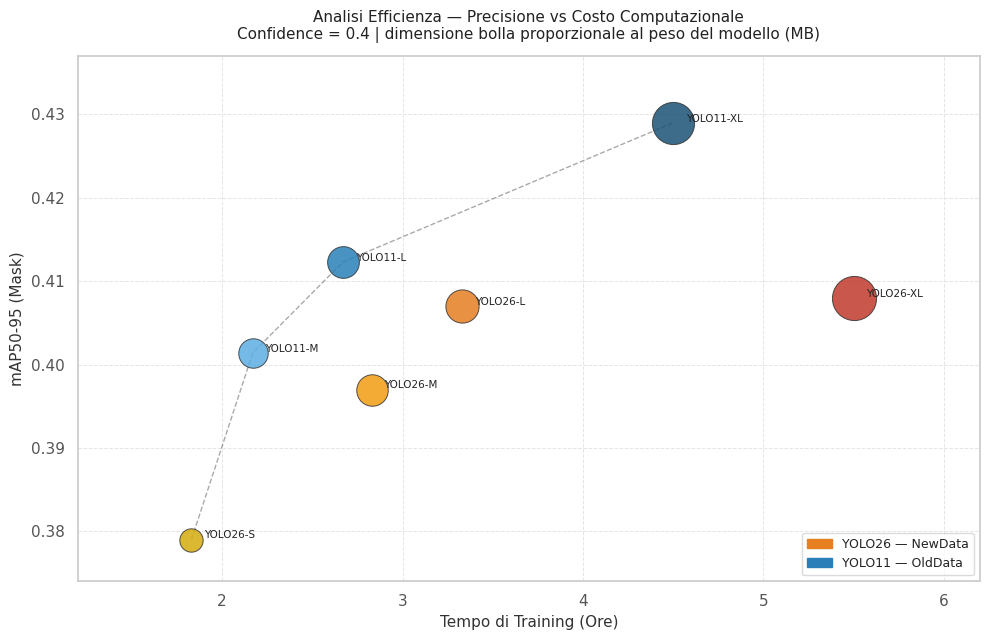


### Analisi dell'Efficienza e Costo Computazionale
| Modello | Peso (MB) | Tempo Training | mAP50-95 (Mask) | Efficienza |
| :--- | :--- | :--- | :--- | :--- |
| **YOLO26-S NewData** | 23.4 MB | 1h 50m | 0.379 | Alta Efficienza |
| **YOLO11-M OldData** | 45.2 MB | 2h 10m | 0.401 | Baseline OldData |
| **YOLO11-L OldData** | 55.8 MB | 2h 40m | 0.412 | Superato da YOLO26-L |
| **YOLO26-M NewData** | 54.5 MB | 2h 50m | 0.397 | Ottimo bilanciamento |
| **YOLO26-L NewData** | 63.5 MB | 3h 20m | 0.407 | Best Performance |
| **YOLO11-XL OldData** | 124.8 MB | 4h 30m | **0.429** | **Inefficiente (OldData)** |
| **YOLO26-XL NewData** | 141.8 MB | 5h 30m | 0.408 | Inefficiente |


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Carica CSV e filtra conf=0.4 ────────────────────────────────────────────
df_raw = pd.read_csv('risultati.csv')
df04 = df_raw[df_raw['Conf'] == 0.4].copy()

# ── Dati aggiuntivi non presenti nel CSV ─────────────────────────────────────
meta = {
    ('ExtraLarge26', 'NewData'): {'peso_mb': 141.8, 'training_h': 5.50, 'label': 'YOLO26-XL'},
    ('Large26',      'NewData'): {'peso_mb':  63.5, 'training_h': 3.33, 'label': 'YOLO26-L'},
    ('Medium26',     'NewData'): {'peso_mb':  54.5, 'training_h': 2.83, 'label': 'YOLO26-M'},
    ('Small26',      'NewData'): {'peso_mb':  23.4, 'training_h': 1.83, 'label': 'YOLO26-S'},
    ('ExtraLarge11', 'OldData'): {'peso_mb': 124.8, 'training_h': 4.50, 'label': 'YOLO11-XL'},
    ('Large11',      'OldData'): {'peso_mb':  55.8, 'training_h': 2.67, 'label': 'YOLO11-L'},
    ('Medium11',     'OldData'): {'peso_mb':  45.2, 'training_h': 2.17, 'label': 'YOLO11-M'},
}

# Costruisci dataframe finale
rows = []
for (model, dataset), info in meta.items():
    row = df04[(df04['Model'] == model) & (df04['Dataset'] == dataset)]
    if row.empty:
        print(f'ATTENZIONE: nessun dato per {model} / {dataset} a conf=0.4')
        continue
    rows.append({
        'label':      info['label'],
        'model':      model,
        'dataset':    dataset,
        'peso_mb':    info['peso_mb'],
        'training_h': info['training_h'],
        'mask5095':   float(row['Mask_mAP50-95'].values[0]),
        'mask50':     float(row['Mask_mAP50'].values[0]),
        'bbox50':     float(row['Box_mAP50'].values[0]),
    })

df = pd.DataFrame(rows)
print(df[['label', 'peso_mb', 'training_h', 'mask50']].to_string(index=False))

# ── Stile bianco ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#cccccc',
    'axes.labelcolor':   '#333333',
    'text.color':        '#222222',
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'grid.color':        '#e5e5e5',
    'grid.linestyle':    '--',
    'grid.linewidth':    0.7,
    'font.family':       'DejaVu Sans',
    'font.size':         10,
})

# ── Palette ───────────────────────────────────────────────────────────────────
# YOLO26 NewData → arancio/rosso saturo (leggibile su bianco)
# YOLO11 OldData → blu intenso
COLORS = {
    'ExtraLarge26': '#C0392B',
    'Large26':      '#E67E22',
    'Medium26':     '#F39C12',
    'Small26':      '#D4AC0D',
    'ExtraLarge11': '#1A5276',
    'Large11':      '#2980B9',
    'Medium11':     '#5DADE2',
}

# ── Figura ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor('white')
ax.grid(True, zorder=0)

# Dimensione bolla proporzionale al peso MB
SCALE = 18
sizes = [((r['peso_mb'] ** 0.6) * SCALE) for _, r in df.iterrows()]

for i, (_, r) in enumerate(df.iterrows()):
    color = COLORS.get(r['model'], '#888888')
    ax.scatter(
        r['training_h'], r['mask50'],
        s=sizes[i] ** 1.18,
        color=color,
        edgecolors='#333333',
        linewidths=0.7,
        alpha=0.85,
        zorder=3,
    )

    # Etichetta accanto alla bolla
    offset_x = 0.07
    offset_y = 0.0005
    ax.annotate(
        r['label'],
        xy=(r['training_h'], r['mask50']),
        xytext=(r['training_h'] + offset_x, r['mask50'] + offset_y),
        fontsize=7.5,
        color='#222222',
        va='center',
        zorder=5,
    )

# ── Pareto frontier ───────────────────────────────────────────────────────────
df_sorted = df.sort_values('training_h')
pareto = []
best_map = -1
for _, r in df_sorted.iterrows():
    if r['mask5095'] > best_map:
        best_map = r['mask5095']
        pareto.append(r)

if len(pareto) > 1:
    px = [r['training_h'] for r in pareto]
    py = [r['mask5095']   for r in pareto]
    ax.plot(px, py,
            color='#555555', linewidth=1.0, linestyle='--',
            alpha=0.5, zorder=2, label='Pareto frontier')

# ── Assi e titolo ─────────────────────────────────────────────────────────────
ax.set_xlabel('Tempo di Training (Ore)', fontsize=11, color='#333333')
ax.set_ylabel('mAP50-95 (Mask)', fontsize=11, color='#333333')
ax.set_title(
    'Analisi Efficienza — Precisione vs Costo Computazionale\n'
    'Confidence = 0.4 | dimensione bolla proporzionale al peso del modello (MB)',
    fontsize=11, color='#222222', pad=12
)

# Margini
ax.set_xlim(1.2, 6.2)
y_min = df['mask5095'].min()
y_max = df['mask5095'].max()
ax.set_ylim(y_min - 0.005, y_max + 0.008)

# Bordo assi più leggero
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

# ── Legenda serie ─────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color='#E67E22', label='YOLO26 — NewData'),
    mpatches.Patch(color='#2980B9', label='YOLO11 — OldData'),
]
ax.legend(handles=legend_handles, loc='lower right',
          framealpha=0.7, fontsize=9,
          facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.show()


# ── Tabella README ────────────────────────────────────────────────────────────
# Etichette di efficienza (personalizza se vuoi)
efficienza_map = {
    'ExtraLarge26': 'Inefficiente',
    'Large26':      'Best Performance',
    'Medium26':     'Ottimo bilanciamento',
    'Small26':      'Alta Efficienza',
    'ExtraLarge11': 'Inefficiente (OldData)',
    'Large11':      'Superato da YOLO26-L',
    'Medium11':     'Baseline OldData',
}

# Ordina per tempo di training crescente
df_table = df.sort_values('training_h').copy()

# Trova il valore massimo di mAP per il bold
best_idx = df_table['mask5095'].idxmax()

# Converti ore decimali in ore + minuti
def h_to_hm(h):
    ore = int(h)
    minuti = round((h - ore) * 60)
    return f"{ore}h {minuti:02d}m"

# Nomi leggibili per il modello
label_clean = {
    'ExtraLarge26': 'YOLO26-XL NewData',
    'Large26':      'YOLO26-L NewData',
    'Medium26':     'YOLO26-M NewData',
    'Small26':      'YOLO26-S NewData',
    'ExtraLarge11': 'YOLO11-XL OldData',
    'Large11':      'YOLO11-L OldData',
    'Medium11':     'YOLO11-M OldData',
}

print()
print("### Analisi dell'Efficienza e Costo Computazionale")
print("| Modello | Peso (MB) | Tempo Training | mAP50-95 (Mask) | Efficienza |")
print("| :--- | :--- | :--- | :--- | :--- |")

for idx, r in df_table.iterrows():
    nome    = f"**{label_clean[r['model']]}**"
    peso    = f"{r['peso_mb']} MB"
    tempo   = h_to_hm(r['training_h'])
    mAP_val = f"{r['mask5095']:.3f}"
    eff     = efficienza_map.get(r['model'], '')

    # Evidenzia il best performer
    if idx == best_idx:
        mAP_str = f"**{mAP_val}**"
        eff_str = f"**{eff}**"
    else:
        mAP_str = mAP_val
        eff_str = eff

    print(f"| {nome} | {peso} | {tempo} | {mAP_str} | {eff_str} |")

    label  peso_mb  training_h  mask50
YOLO26-XL    141.8        5.50  0.7430
 YOLO26-L     63.5        3.33  0.7240
 YOLO26-M     54.5        2.83  0.7220
 YOLO26-S     23.4        1.83  0.6820
YOLO11-XL    124.8        4.50  0.7405
 YOLO11-L     55.8        2.67  0.7320
 YOLO11-M     45.2        2.17  0.7167


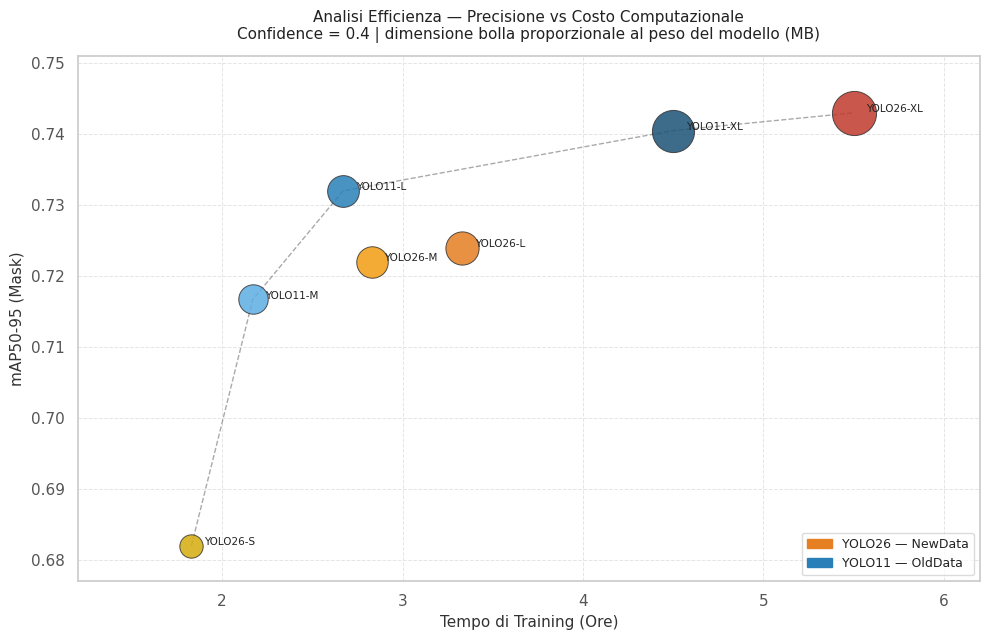


### Analisi dell'Efficienza e Costo Computazionale
| Modello | Peso (MB) | Tempo Training | mAP50-95 (Mask) | Efficienza |
| :--- | :--- | :--- | :--- | :--- |
| **YOLO26-S NewData** | 23.4 MB | 1h 50m | 0.682 | Alta Efficienza |
| **YOLO11-M OldData** | 45.2 MB | 2h 10m | 0.717 | Baseline OldData |
| **YOLO11-L OldData** | 55.8 MB | 2h 40m | 0.732 | Superato da YOLO26-L |
| **YOLO26-M NewData** | 54.5 MB | 2h 50m | 0.722 | Ottimo bilanciamento |
| **YOLO26-L NewData** | 63.5 MB | 3h 20m | 0.724 | Best Performance |
| **YOLO11-XL OldData** | 124.8 MB | 4h 30m | 0.741 | Inefficiente (OldData) |
| **YOLO26-XL NewData** | 141.8 MB | 5h 30m | **0.743** | **Inefficiente** |


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Carica CSV e filtra conf=0.4 ────────────────────────────────────────────
df_raw = pd.read_csv('risultati.csv')
df04 = df_raw[df_raw['Conf'] == 0.4].copy()

# ── Dati aggiuntivi non presenti nel CSV ─────────────────────────────────────
meta = {
    ('ExtraLarge26', 'NewData'): {'peso_mb': 141.8, 'training_h': 5.50, 'label': 'YOLO26-XL'},
    ('Large26',      'NewData'): {'peso_mb':  63.5, 'training_h': 3.33, 'label': 'YOLO26-L'},
    ('Medium26',     'NewData'): {'peso_mb':  54.5, 'training_h': 2.83, 'label': 'YOLO26-M'},
    ('Small26',      'NewData'): {'peso_mb':  23.4, 'training_h': 1.83, 'label': 'YOLO26-S'},
    ('ExtraLarge11', 'OldData'): {'peso_mb': 124.8, 'training_h': 4.50, 'label': 'YOLO11-XL'},
    ('Large11',      'OldData'): {'peso_mb':  55.8, 'training_h': 2.67, 'label': 'YOLO11-L'},
    ('Medium11',     'OldData'): {'peso_mb':  45.2, 'training_h': 2.17, 'label': 'YOLO11-M'},
}

# Costruisci dataframe finale
rows = []
for (model, dataset), info in meta.items():
    row = df04[(df04['Model'] == model) & (df04['Dataset'] == dataset)]
    if row.empty:
        print(f'ATTENZIONE: nessun dato per {model} / {dataset} a conf=0.4')
        continue
    rows.append({
        'label':      info['label'],
        'model':      model,
        'dataset':    dataset,
        'peso_mb':    info['peso_mb'],
        'training_h': info['training_h'],
        'mask5095':   float(row['Mask_mAP50-95'].values[0]),
        'mask50':     float(row['Mask_mAP50'].values[0]),
        'bbox50':     float(row['Box_mAP50'].values[0]),
    })

df = pd.DataFrame(rows)
print(df[['label', 'peso_mb', 'training_h', 'mask50']].to_string(index=False))

# ── Stile bianco ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#cccccc',
    'axes.labelcolor':   '#333333',
    'text.color':        '#222222',
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'grid.color':        '#e5e5e5',
    'grid.linestyle':    '--',
    'grid.linewidth':    0.7,
    'font.family':       'DejaVu Sans',
    'font.size':         10,
})

# ── Palette ───────────────────────────────────────────────────────────────────
# YOLO26 NewData → arancio/rosso saturo (leggibile su bianco)
# YOLO11 OldData → blu intenso
COLORS = {
    'ExtraLarge26': '#C0392B',
    'Large26':      '#E67E22',
    'Medium26':     '#F39C12',
    'Small26':      '#D4AC0D',
    'ExtraLarge11': '#1A5276',
    'Large11':      '#2980B9',
    'Medium11':     '#5DADE2',
}

# ── Figura ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor('white')
ax.grid(True, zorder=0)

# Dimensione bolla proporzionale al peso MB
SCALE = 18
sizes = [((r['peso_mb'] ** 0.6) * SCALE) for _, r in df.iterrows()]

for i, (_, r) in enumerate(df.iterrows()):
    color = COLORS.get(r['model'], '#888888')
    ax.scatter(
        r['training_h'], r['mask50'],
        s=sizes[i] ** 1.18,
        color=color,
        edgecolors='#333333',
        linewidths=0.7,
        alpha=0.85,
        zorder=3,
    )

    # Etichetta accanto alla bolla
    offset_x = 0.07
    offset_y = 0.0005
    ax.annotate(
        r['label'],
        xy=(r['training_h'], r['mask50']),
        xytext=(r['training_h'] + offset_x, r['mask50'] + offset_y),
        fontsize=7.5,
        color='#222222',
        va='center',
        zorder=5,
    )

# ── Pareto frontier ───────────────────────────────────────────────────────────
df_sorted = df.sort_values('training_h')
pareto = []
best_map = -1
for _, r in df_sorted.iterrows():
    if r['mask50'] > best_map:
        best_map = r['mask50']
        pareto.append(r)

if len(pareto) > 1:
    px = [r['training_h'] for r in pareto]
    py = [r['mask50']   for r in pareto]
    ax.plot(px, py,
            color='#555555', linewidth=1.0, linestyle='--',
            alpha=0.5, zorder=2, label='Pareto frontier')

# ── Assi e titolo ─────────────────────────────────────────────────────────────
ax.set_xlabel('Tempo di Training (Ore)', fontsize=11, color='#333333')
ax.set_ylabel('mAP50-95 (Mask)', fontsize=11, color='#333333')
ax.set_title(
    'Analisi Efficienza — Precisione vs Costo Computazionale\n'
    'Confidence = 0.4 | dimensione bolla proporzionale al peso del modello (MB)',
    fontsize=11, color='#222222', pad=12
)

# Margini
ax.set_xlim(1.2, 6.2)
y_min = df['mask50'].min()
y_max = df['mask50'].max()
ax.set_ylim(y_min - 0.005, y_max + 0.008)

# Bordo assi più leggero
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

# ── Legenda serie ─────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color='#E67E22', label='YOLO26 — NewData'),
    mpatches.Patch(color='#2980B9', label='YOLO11 — OldData'),
]
ax.legend(handles=legend_handles, loc='lower right',
          framealpha=0.7, fontsize=9,
          facecolor='white', edgecolor='#cccccc')

plt.tight_layout()
plt.show()


# ── Tabella README ────────────────────────────────────────────────────────────
# Etichette di efficienza (personalizza se vuoi)
efficienza_map = {
    'ExtraLarge26': 'Inefficiente',
    'Large26':      'Best Performance',
    'Medium26':     'Ottimo bilanciamento',
    'Small26':      'Alta Efficienza',
    'ExtraLarge11': 'Inefficiente (OldData)',
    'Large11':      'Superato da YOLO26-L',
    'Medium11':     'Baseline OldData',
}

# Ordina per tempo di training crescente
df_table = df.sort_values('training_h').copy()

# Trova il valore massimo di mAP per il bold
best_idx = df_table['mask50'].idxmax()

# Converti ore decimali in ore + minuti
def h_to_hm(h):
    ore = int(h)
    minuti = round((h - ore) * 60)
    return f"{ore}h {minuti:02d}m"

# Nomi leggibili per il modello
label_clean = {
    'ExtraLarge26': 'YOLO26-XL NewData',
    'Large26':      'YOLO26-L NewData',
    'Medium26':     'YOLO26-M NewData',
    'Small26':      'YOLO26-S NewData',
    'ExtraLarge11': 'YOLO11-XL OldData',
    'Large11':      'YOLO11-L OldData',
    'Medium11':     'YOLO11-M OldData',
}

print()
print("### Analisi dell'Efficienza e Costo Computazionale")
print("| Modello | Peso (MB) | Tempo Training | mAP50-95 (Mask) | Efficienza |")
print("| :--- | :--- | :--- | :--- | :--- |")

for idx, r in df_table.iterrows():
    nome    = f"**{label_clean[r['model']]}**"
    peso    = f"{r['peso_mb']} MB"
    tempo   = h_to_hm(r['training_h'])
    mAP_val = f"{r['mask50']:.3f}"
    eff     = efficienza_map.get(r['model'], '')

    # Evidenzia il best performer
    if idx == best_idx:
        mAP_str = f"**{mAP_val}**"
        eff_str = f"**{eff}**"
    else:
        mAP_str = mAP_val
        eff_str = eff

    print(f"| {nome} | {peso} | {tempo} | {mAP_str} | {eff_str} |")

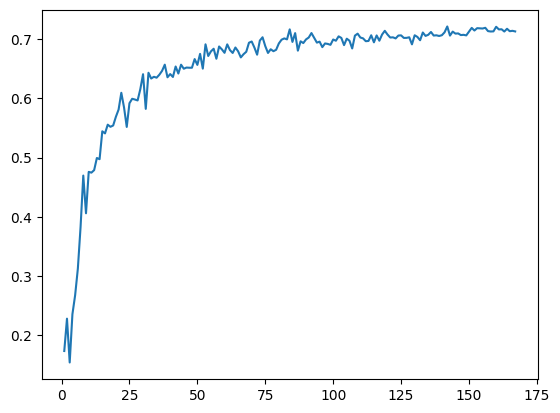

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.read_csv("yolo8Large/results.csv")

plt.plot(results["epoch"], results['metrics/mAP50(M)'])
plt.show()

In [3]:
from ultralytics.data.utils import check_det_dataset
from ultralytics.utils import DEFAULT_CFG

# Carica le informazioni dal file yaml
data_info = check_det_dataset('versioniPrecedenti/datasetPomodori/data.yaml')

data_info
# Se il dataset è già stato scansionato, le statistiche sono in data_info
# Nota: Questo metodo è ottimale per verificare la coerenza del file YAML

{'train': 'C:\\Users\\loren\\Desktop\\tirocinio\\modelliPomodori\\versioniPrecedenti\\datasetPomodori\\train\\images',
 'val': 'C:\\Users\\loren\\Desktop\\tirocinio\\modelliPomodori\\versioniPrecedenti\\datasetPomodori\\valid\\images',
 'test': 'C:\\Users\\loren\\Desktop\\tirocinio\\modelliPomodori\\versioniPrecedenti\\datasetPomodori\\test\\images',
 'nc': 4,
 'names': {0: '6kp_peduncle', 1: '6kp_petiole', 2: 'MainStem', 3: 'tomato'},
 'roboflow': {'workspace': 'pomodori-gqsky',
  'project': 'pomodori',
  'version': 1,
  'license': 'Private',
  'url': 'https://app.roboflow.com/pomodori-gqsky/pomodori/1'},
 'yaml_file': 'versioniPrecedenti/datasetPomodori/data.yaml',
 'channels': 3,
 'path': WindowsPath('versioniPrecedenti/datasetPomodori')}

In [6]:
import os
from collections import Counter

# Recuperiamo il percorso delle immagini e risaliamo alle labels
# In YOLO, solitamente le cartelle sono speculari: ../images/ e ../labels/
train_images_path = r'C:\Users\loren\Desktop\tirocinio\modelliPomodori\versioniPrecedenti\datasetPomodori\train\images'
train_labels_path = train_images_path.replace('images', 'labels')

class_names = {0: '6kp_peduncle', 1: '6kp_petiole', 2: 'MainStem', 3: 'tomato'}
stats = Counter()

if os.path.exists(train_labels_path):
    label_files = [f for f in os.listdir(train_labels_path) if f.endswith('.txt')]
    
    for file in label_files:
        with open(os.path.join(train_labels_path, file), 'r') as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    stats[class_id] += 1

    print("--- Statistiche Dataset di Addestramento ---")
    for idx, name in class_names.items():
        print(f"Classe {idx} ({name}): {stats[idx]} istanze")
else:
    print(f"Errore: Percorso {train_labels_path} non trovato.")

--- Statistiche Dataset di Addestramento ---
Classe 0 (6kp_peduncle): 1361 istanze
Classe 1 (6kp_petiole): 3020 istanze
Classe 2 (MainStem): 6060 istanze
Classe 3 (tomato): 37361 istanze


In [8]:
import json
from collections import Counter

# Percorso del file esportato da Roboflow
json_path = 'annotations.json'

with open(json_path, 'r') as f:
    data = json.load(f)

# 1. Creazione mappatura ID -> Nome Classe
categories = {cat['id']: cat['name'] for cat in data['categories']}

# 2. Conteggio istanze nella sezione 'annotations'
instance_counts = Counter([ann['category_id'] for ann in data['annotations']])

# 3. Conteggio immagini uniche
total_images = len(data['images'])

print(f"--- Report Analitico dal File JSON ---")
print(f"Totale Immagini: {total_images}")
print(f"Totale Istanze rilevate: {sum(instance_counts.values())}")
print("-" * 30)

for cat_id, count in instance_counts.items():
    class_name = categories.get(cat_id, "Unknown")
    print(f"Classe {cat_id} ({class_name}): {count} istanze")

--- Report Analitico dal File JSON ---
Totale Immagini: 756
Totale Istanze rilevate: 23779
------------------------------
Classe 1380661885 (MainStem): 2969 istanze
Classe 1380661889 (tomato): 18675 istanze
Classe 2 (6kp_petiole): 1484 istanze
Classe 1 (6kp_peduncle): 651 istanze


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione stile accademico
sns.set_theme(style="whitegrid", rc={"text.usetex": False})
plt.rcParams.update({'font.size': 12, 'font.family': 'serif'})

# Caricamento dati
# Assicurati che il file contenga le colonne: 'Model', 'Conf', 'Precision', 'Recall' [cite: 286]
df = pd.read_csv('risultati.csv')

# Selezione del modello (es. YOLO11-Large) [cite: 109, 360]
modello_target = 'Large11' 
df_plot = df[df['Model'] == modello_target].copy()
df_plot = df_plot.sort_values(by='Conf')

# Trasformazione dei dati per Seaborn (Melt)
# Questo permette di avere una colonna per il valore e una per il nome della metrica
df_melted = df_plot.melt(
    id_vars=['Conf', 'Model'], 
    value_vars=['Precision', 'Recall'], 
    var_name='Metrica', 
    value_name='Score'
)

# Creazione del grafico
plt.figure(figsize=(10, 6))

plot = sns.lineplot(
    data=df_melted,
    x='Conf',
    y='Score',
    hue='Metrica',
    style='Metrica',
    markers=True,
    dashes=False,
    linewidth=2.5,
    palette={'Precision': '#1f77b4', 'Recall': '#ff7f0e'} # Blu e Arancione standard
)

# Personalizzazione assi e titoli
plt.title(f"Trade-off Precision-Recall: {modello_target}", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Confidence Threshold (Soglia di Confidenza)", fontsize=13)
plt.ylabel("Valore Metrica (0.0 - 1.0)", fontsize=13)

plt.xlim(0, 1.0)
plt.ylim(0, 1.05) # Leggermente sopra 1 per respiro visivo
plt.xticks(ticks=[i/10 for i in range(11)]) # Step di 0.1

# Posizionamento legenda
plt.legend(title="Metriche", frameon=True, loc='lower left')

# Nota tecnica: il punto di intersezione massimizza l'F1-Score
plt.tight_layout()

# Salvataggio per la tesi
# plt.savefig(f'tradeoff_PR_{modello_target}.png', dpi=300, bbox_inches='tight')

plt.show()

NameError: name 'sns' is not defined

<Figure size 1000x600 with 0 Axes>